In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl
from smarts_cerebellum.util import preprocess_tract_df

In [4]:
CST_WM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_WM_mod_slope.tsv'), sep = '\t') 
CST_WM['hemisphere'] = CST_WM.regionname.str.split('_', expand=True).loc[:, 0]
CST_WM['group'] = np.where(CST_WM.isPatient == 0, 'controls', np.where(CST_WM.hemisphere == 'right', 'contralesional', 'ipsilesional'))
CST_WM = CST_WM.groupby(['subj_id', 'regionname', 'group']).mean(numeric_only=True).reset_index()

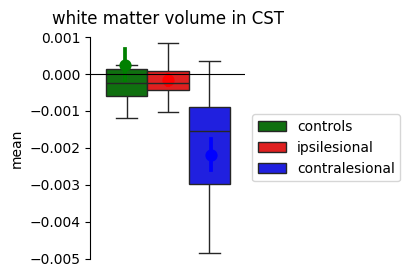

In [5]:
colours = ['green', 'r', 'blue']
fig, ax = plt.subplots(figsize=(2, 3))
sns.boxplot(data=CST_WM, y='mean', hue = 'group', showfliers=False, palette = colours)
sns.pointplot(data=CST_WM, y='mean', hue = 'group', errorbar='se', dodge=.55, legend=False, palette = colours)
# sns.violinplot(data=CST_WM, y='mean', hue = 'group',)

ax.axhline(0, ls='-', lw=.8, color='k')

ax.legend(bbox_to_anchor=(1, .5), loc='center left')
ax.set_xticks([])

sns.despine(trim = True, bottom=True)
plt.title('white matter volume in CST')

fig.savefig('figure/WMV_CST.pdf')

plt.show()

In [4]:
t_val, p_val = stats.ttest_ind(CST_WM[CST_WM.group=='ipsilesional']['mean'], CST_WM[CST_WM.group=='controls']['mean'])
print(f'**t-test for WM CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(CST_WM[CST_WM.group=='contralesional']['mean'], CST_WM[CST_WM.group=='controls']['mean'])
print(f'**t-test for WM CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_rel(CST_WM[CST_WM.group=='contralesional']['mean'], CST_WM[CST_WM.group=='ipsilesional']['mean'])
print(f'**t-test for WM CST: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')



**t-test for WM CST: lesion side in patients, controls** 
 t-value: -1.1033650876565908 	 p-value: 0.2745875860323665


**t-test for WM CST: non-lesion side in patients, controls** 
 t-value: -3.851517158666986 	 p-value: 0.00030413179138631934


**t-test for WM CST: within patients, left, right hemispheres** 
 t-value: -4.494347663883597 	 p-value: 7.311562721739249e-05


